In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

plt.rcParams["figure.figsize"]=(10,5)

In [6]:
df = pd.read_csv("data/online_retail_II.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'data/online_retail_II.csv'

In [ ]:
df.head()

In [ ]:
df.info()

In [ ]:
df.isnull().sum()

In [4]:
import os
print(os.getcwd())

c:\Users\sanik\Desktop\Customer_Retention_Project


In [7]:
import os

print(os.listdir())

['dashboard', 'data', 'eda.ipynb', 'models', 'notebooks', 'online_retail.csv', 'online_retail_II.csv', 'reports']


In [8]:
df = pd.read_csv("online_retail_II.csv", encoding="ISO-8859-1")

PermissionError: [Errno 13] Permission denied: 'online_retail_II.csv'

In [9]:
import os

print(os.path.isfile("online_retail_II.csv"))
print(os.path.isdir("online_retail_II.csv"))

False
True


In [10]:
import os

for item in os.listdir():
    print(item, "->", "File" if os.path.isfile(item) else "Folder")

dashboard -> Folder
data -> File
eda.ipynb -> File
models -> Folder
notebooks -> File
online_retail.csv -> File
online_retail_II.csv -> Folder
reports -> Folder


In [11]:
import os

print(os.listdir("online_retail_II.csv"))

['online_retail_II.csv']


In [13]:
df = pd.read_csv(
    "online_retail_II.csv/online_retail_II.csv",
    encoding="ISO-8859-1"
)

In [14]:
import os
print(os.path.abspath("online_retail_II.csv/online_retail_II.csv"))

c:\Users\sanik\Desktop\Customer_Retention_Project\online_retail_II.csv\online_retail_II.csv


In [15]:
df = pd.read_csv(
    r"C:\Users\sanik\Desktop\Customer_Retention_Project\online_retail_II.csv\online_retail_II.csv",
    encoding="ISO-8859-1"
)

In [16]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [17]:
print(df.shape)

df.info()

df.isnull().sum()

(1067371, 8)
<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB


Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [18]:
print("Rows and Columns :", df.shape)

Rows and Columns : (1067371, 8)


In [19]:
print("Rows and Columns :", df.shape)

Rows and Columns : (1067371, 8)


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB


In [21]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [22]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [23]:
df_work = df.copy()

In [25]:
df_work = df_work.dropna(subset=["Customer ID"])

In [26]:
df_work.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

In [27]:
df_work = df_work[
    ~df_work["Invoice"].astype(str).str.startswith("C")
]

In [28]:
df_work = df_work[df_work["Quantity"] > 0]

In [29]:
df_work = df_work[df_work["Price"] > 0]

In [30]:
df_work["TotalPrice"] = (
    df_work["Quantity"] *
    df_work["Price"]
)

In [ ]:
df_work.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [32]:
df_work.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [33]:
df_work.drop_duplicates(inplace=True)

In [34]:
print(df_work.shape)

(779425, 9)


##### EDA 

In [35]:
df_work.describe()

,Quantity,Price,Customer ID,TotalPrice
count,779425.000000,779425.000000,779425.000000,779425.000000
mean,13.489370,3.218488,15320.360461,22.291823
std,145.855814,29.676140,1695.692775,227.427075
min,1.000000,0.001000,12346.000000,0.001000
25%,2.000000,1.250000,13971.000000,4.950000
50%,6.000000,1.950000,15247.000000,12.480000
75%,12.000000,3.750000,16794.000000,19.800000
max,80995.000000,10953.500000,18287.000000,168469.600000


In [36]:
top_countries = df_work["Country"].value_counts().head(10)

print(top_countries)

Country
United Kingdom    700388
Germany            16432
EIRE               15565
France             13511
Netherlands         5085
Spain               3662
Belgium             3055
Switzerland         3005
Portugal            2356
Australia           1789
Name: count, dtype: int64


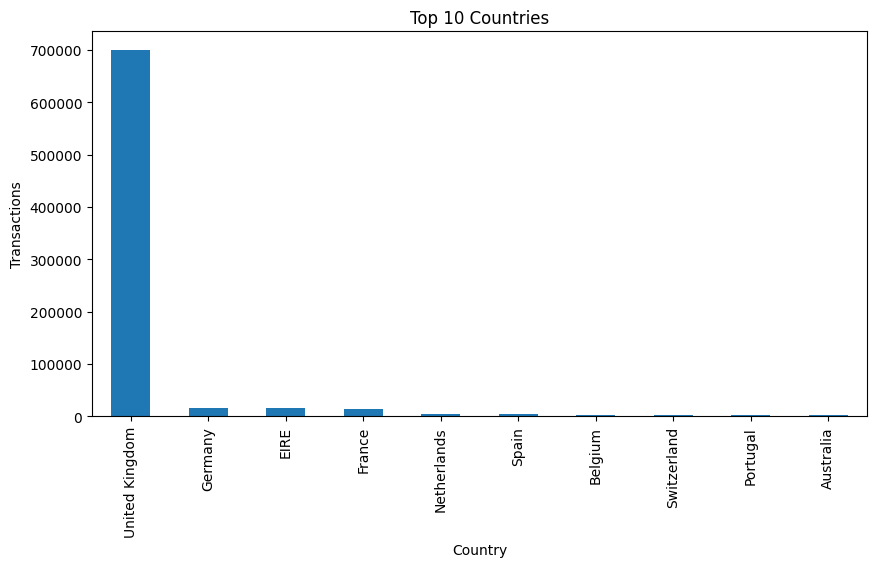

In [38]:
top_countries.plot(kind="bar")

plt.title("Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Transactions")

plt.show()

In [40]:
top_customers = (
    df_work.groupby("Customer ID")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_customers)

Customer ID
18102.0    580987.04
14646.0    528602.52
14156.0    313437.62
14911.0    291420.81
17450.0    244784.25
13694.0    195640.69
17511.0    172132.87
16446.0    168472.50
16684.0    147142.77
12415.0    144458.37
Name: TotalPrice, dtype: float64


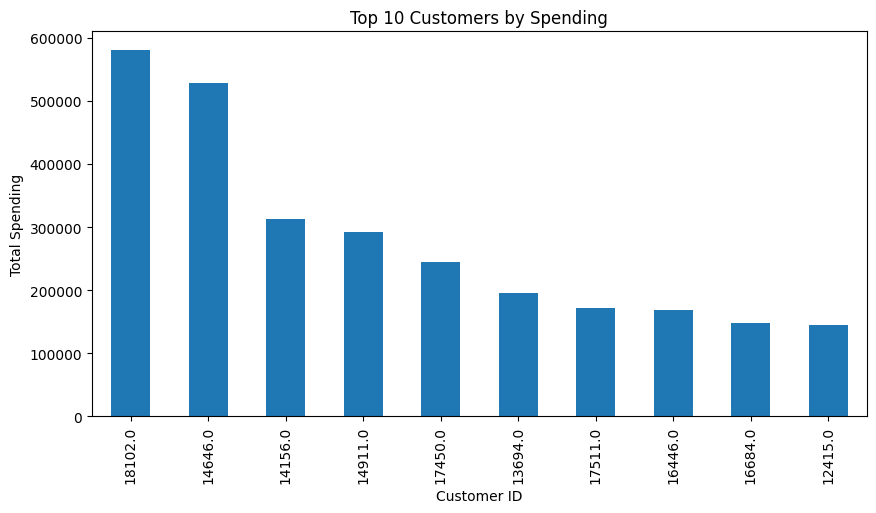

In [41]:
top_customers.plot(kind="bar")

plt.title("Top 10 Customers by Spending")
plt.ylabel("Total Spending")

plt.show()

In [42]:
df_work["InvoiceDate"] = pd.to_datetime(df_work["InvoiceDate"])

In [43]:
df_work["Month"] = (
    df_work["InvoiceDate"]
    .dt.to_period("M")
    .astype(str)
)

In [44]:
monthly_sales = (
    df_work.groupby("Month")["TotalPrice"]
    .sum()
)

print(monthly_sales)

Month
2009-12     683504.010
2010-01     555802.672
2010-02     504558.956
2010-03     696978.471
2010-04     591982.002
2010-05     597833.380
2010-06     636371.130
2010-07     589736.170
2010-08     602224.600
2010-09     829013.951
2010-10    1033112.010
2010-11    1166460.022
2010-12     570422.730
2011-01     568101.310
2011-02     446084.920
2011-03     594081.760
2011-04     468374.331
2011-05     677355.150
2011-06     660046.050
2011-07     598962.901
2011-08     644051.040
2011-09     950690.202
2011-10    1035642.450
2011-11    1156205.610
2011-12     517208.440
Name: TotalPrice, dtype: float64


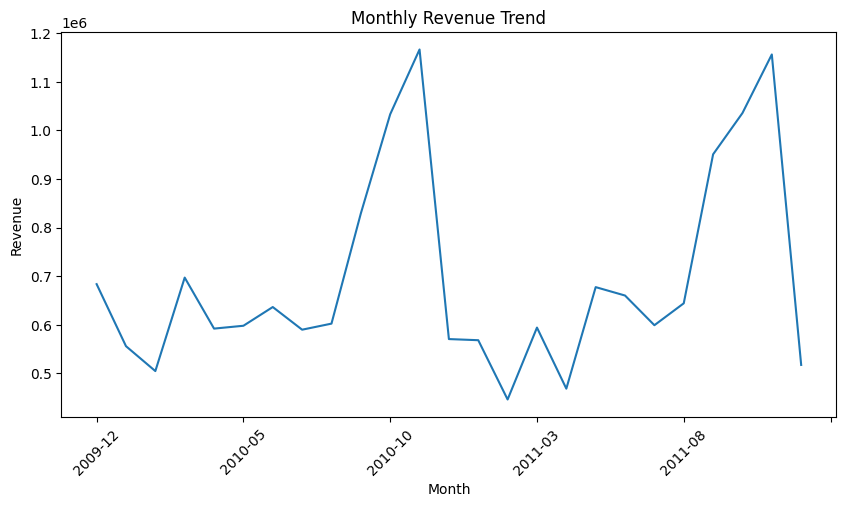

In [45]:
monthly_sales.plot()

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

In [46]:
print(
    "Average Transaction Value :",
    round(df_work["TotalPrice"].mean(),2)
)

Average Transaction Value : 22.29


In [47]:
df_work.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
TotalPrice     0
Month          0
dtype: int64

In [48]:
print(df_work.duplicated().sum())

0


In [49]:
df_work.info()

<class 'pandas.DataFrame'>
Index: 779425 entries, 0 to 1067370
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      779425 non-null  str           
 1   StockCode    779425 non-null  str           
 2   Description  779425 non-null  str           
 3   Quantity     779425 non-null  int64         
 4   InvoiceDate  779425 non-null  datetime64[us]
 5   Price        779425 non-null  float64       
 6   Customer ID  779425 non-null  float64       
 7   Country      779425 non-null  str           
 8   TotalPrice   779425 non-null  float64       
 9   Month        779425 non-null  str           
dtypes: datetime64[us](1), float64(3), int64(1), str(5)
memory usage: 65.4 MB


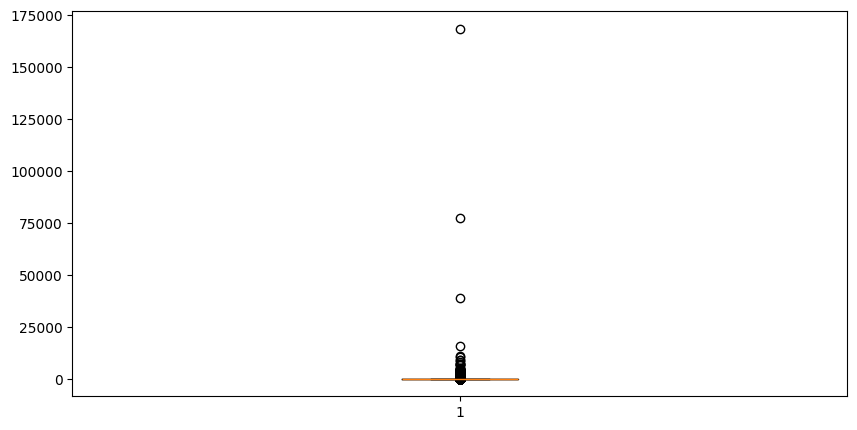

In [50]:
plt.boxplot(df_work["TotalPrice"])
plt.show()

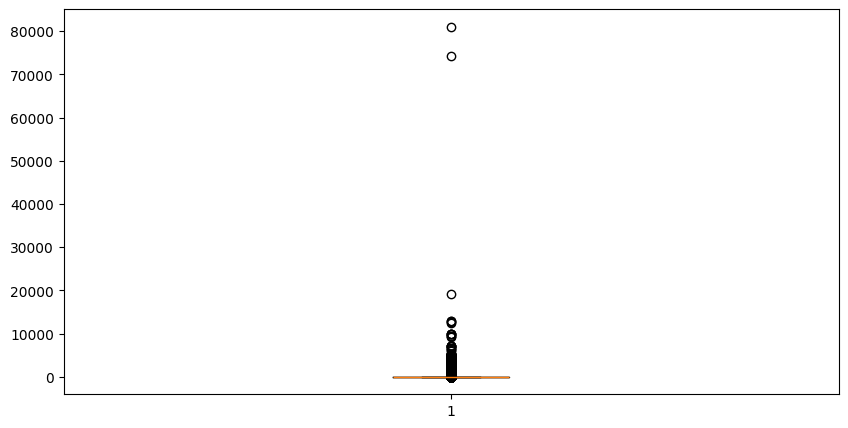

In [52]:
plt.boxplot(df_work["Quantity"])
plt.show()

In [53]:
print(df_work["Customer ID"].nunique())

5878


In [54]:
df_work.to_csv(
    "clean_online_retail.csv",
    index=False
)

In [55]:
print(df_work.duplicated().sum())

0


In [56]:
print(df_work["Customer ID"].nunique())

5878


In [57]:
df_work.to_csv(
    "clean_online_retail.csv",
    index=False
)

print("Clean dataset saved successfully!")

Clean dataset saved successfully!


# Feature Egnieering

##### RFM 

In [58]:
df_work["InvoiceDate"] = pd.to_datetime(df_work["InvoiceDate"])

snapshot_date = df_work["InvoiceDate"].max()

print(snapshot_date)

2011-12-09 12:50:00


####### Creating RFM table

In [59]:
rfm = df_work.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "Invoice": "nunique",
    "TotalPrice": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,325,12,77556.46
12347.0,1,8,4921.53
12348.0,74,5,2019.40
12349.0,18,4,4428.69
12350.0,309,1,334.40


In [60]:
print(rfm.shape)

(5878, 3)


In [61]:
rfm.describe()

,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,200.331916,6.289384,2955.904095
std,209.338707,13.009406,14440.852688
min,0.000000,1.000000,2.950000
25%,25.000000,1.000000,342.280000
50%,95.000000,3.000000,867.740000
75%,379.000000,7.000000,2248.305000
max,738.000000,398.000000,580987.040000


In [62]:
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,325,12,77556.46
12347.0,1,8,4921.53
12348.0,74,5,2019.40
12349.0,18,4,4428.69
12350.0,309,1,334.40


In [63]:
print(rfm.shape)

(5878, 3)


Create R Score

In [64]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5,4,3,2,1]
)

Create F Score

In [65]:
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

Create M Score

In [66]:
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1,2,3,4,5]
)

Create Combined RFM Score

In [67]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

In [68]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
Customer ID,,,,,,,
12346.0,325,12,77556.46,2,5,5,255
12347.0,1,8,4921.53,5,4,5,545
12348.0,74,5,2019.40,3,4,4,344
12349.0,18,4,4428.69,5,3,5,535
12350.0,309,1,334.40,2,1,2,212


In [69]:
rfm["RFM_Score"].value_counts().head(20)

RFM_Score
555    469
111    317
455    248
121    172
211    165
344    164
112    152
444    147
122    135
544    131
355    131
221    122
222    119
233    110
333    106
433    104
232    100
212     98
554     96
311     93
Name: count, dtype: int64

In [70]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
Customer ID,,,,,,,
12346.0,325,12,77556.46,2,5,5,255
12347.0,1,8,4921.53,5,4,5,545
12348.0,74,5,2019.40,3,4,4,344
12349.0,18,4,4428.69,5,3,5,535
12350.0,309,1,334.40,2,1,2,212
